In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# task 1

train_df = pd.read_csv('Hourly-train.csv')
test_df = pd.read_csv('Hourly-test.csv')

train_df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V952,V953,V954,V955,V956,V957,V958,V959,V960,V961
0,H1,605.0,586.0,586.0,559.0,511.0,443.0,422.0,395.0,382.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H2,3124.0,2990.0,2862.0,2809.0,2544.0,2201.0,1996.0,1861.0,1735.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H3,1828.0,1806.0,1897.0,1750.0,1679.0,1620.0,1463.0,1342.0,1192.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,H4,6454.0,6324.0,6075.0,5949.0,5858.0,5579.0,5163.0,4790.0,4478.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,H5,4263.0,4297.0,4236.0,4080.0,3883.0,3672.0,3248.0,2841.0,2513.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
test_df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49
0,H1,619.0,565.0,532.0,495.0,481.0,467.0,473.0,488.0,501.0,...,812.0,836.0,838.0,829.0,807.0,785.0,756.0,719.0,703.0,659.0
1,H2,2771.0,2396.0,2189.0,1984.0,1872.0,1843.0,1828.0,1872.0,1952.0,...,3018.0,3206.0,3356.0,3499.0,3550.0,3558.0,3488.0,3224.0,3054.0,2918.0
2,H3,1455.0,1376.0,1235.0,1101.0,1003.0,943.0,905.0,886.0,910.0,...,1457.0,1529.0,1627.0,1701.0,1754.0,1791.0,1819.0,1791.0,1758.0,1679.0
3,H4,5327.0,5051.0,4683.0,4319.0,4049.0,3847.0,3712.0,3639.0,3652.0,...,5337.0,5675.0,5926.0,6159.0,6313.0,6072.0,5612.0,5220.0,4895.0,4793.0
4,H5,3823.0,3501.0,3039.0,2613.0,2312.0,2079.0,1938.0,1839.0,1821.0,...,2345.0,2529.0,2737.0,3028.0,3292.0,3453.0,3574.0,3522.0,3338.0,3041.0


In [ ]:
h7_train = train_df[train_df['V1'] == 'H7'].dropna(axis=1).iloc[:, 1:].values.flatten()
h7_test = test_df[test_df['V1'] == 'H7'].dropna(axis=1).iloc[:, 1:].values.flatten()

In [14]:
h7_test_27_target = h7_test[:24]
h7_test_27_target

array([49671., 48177., 45276., 40964., 37108., 34361., 32397., 31065.,
       30340., 30674., 31925., 33551., 35688., 37917., 40002., 42428.,
       44737., 47109., 49713., 51339., 52088., 52421., 51531., 49597.])

In [17]:
start_date = '2015-01-07 12:00:00'
date_rng = pd.date_range(start=start_date, periods=len(h7_train), freq='h')
train_series = pd.Series(h7_train, index=date_rng)

print(f"Train len -> {len(train_series)}")
print(f"Test len -> {len(h7_test)}")

Train len -> 700
Test len -> 48


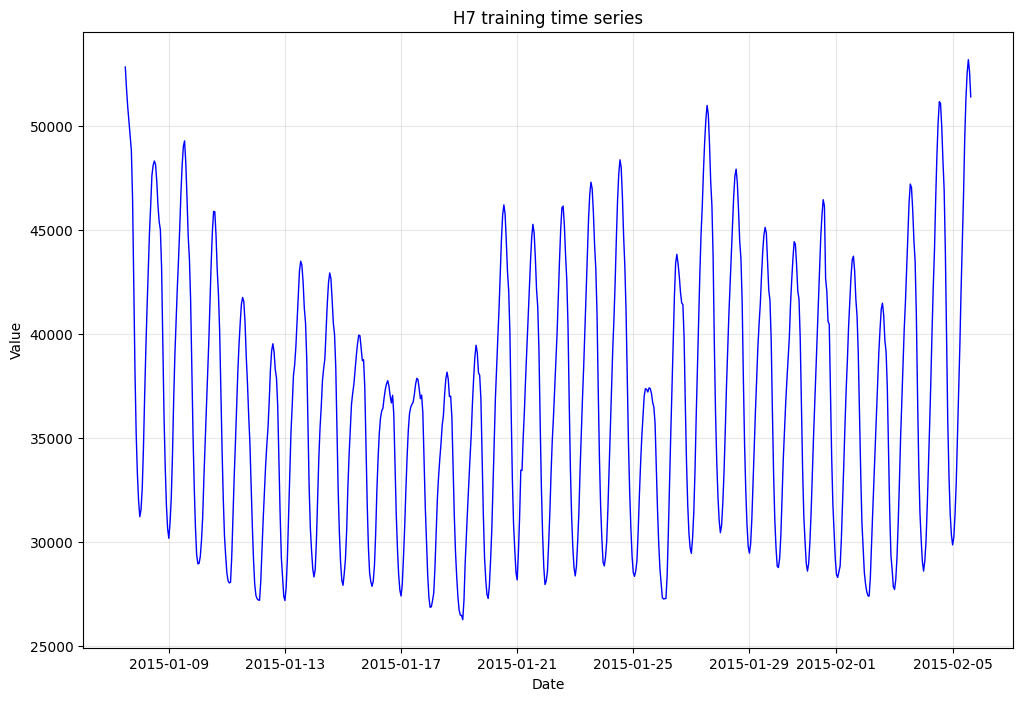

In [24]:
plt.figure(figsize=(12, 8))
plt.plot(train_series, color='blue', linewidth=1)
plt.title('H7 training time series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

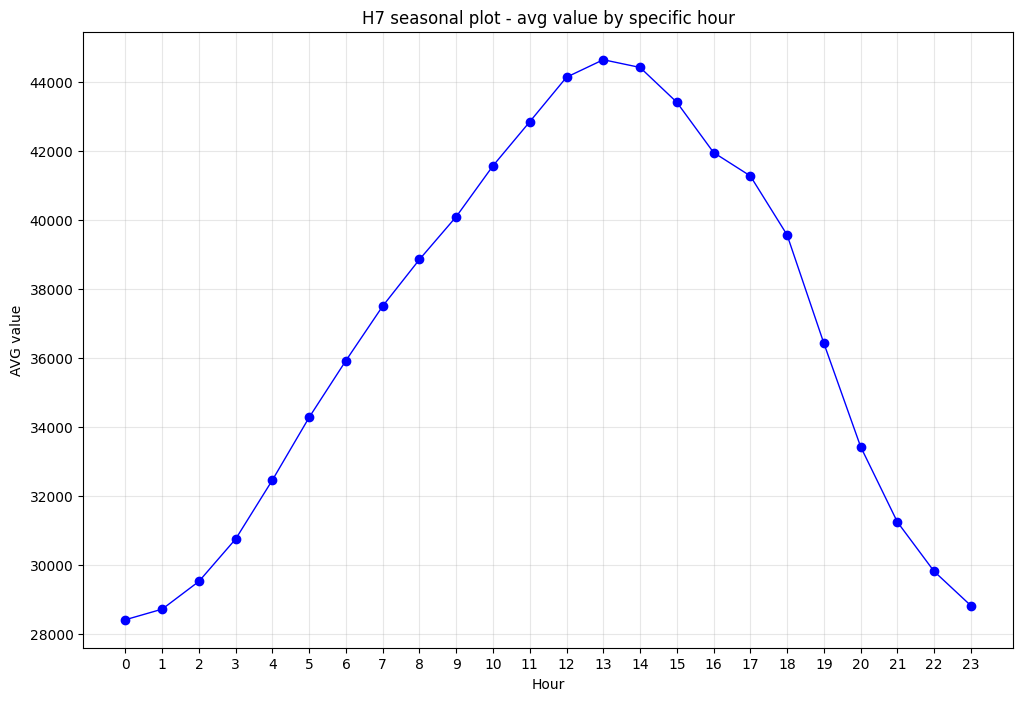

In [48]:
seasonal_pattern = train_series.groupby(train_series.index.hour).mean()
plt.figure(figsize=(12, 8))
plt.plot(seasonal_pattern.index, seasonal_pattern.values, marker='o', color='blue', linewidth=1)
plt.title('H7 seasonal plot - avg value by specific hour')
plt.xlabel('Hour')
plt.ylabel('AVG value')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

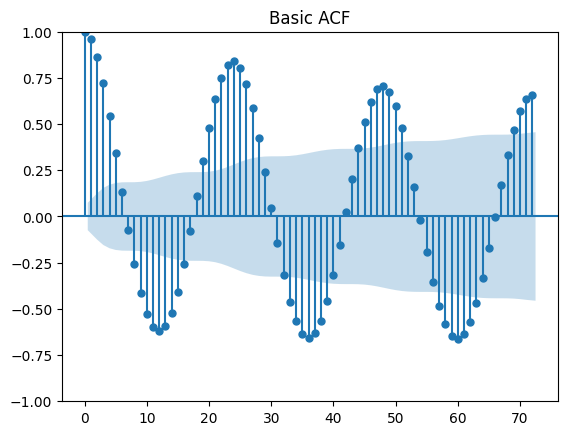

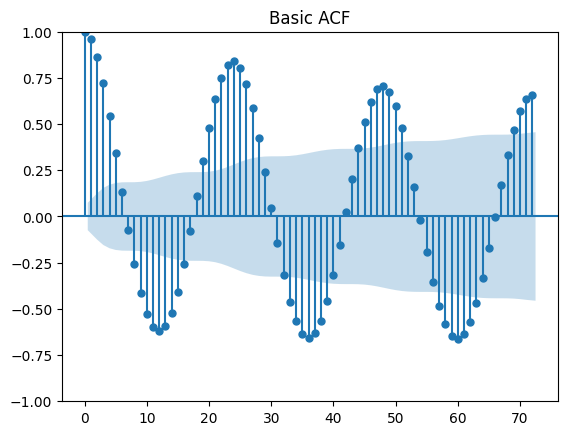

In [50]:
plot_acf(train_series, lags=72, title='Basic ACF')

In [19]:
print(train_series.describe())

count      700.000000
mean     36718.152857
std       6351.335330
min      26245.000000
25%      31075.750000
50%      36597.500000
75%      41536.000000
max      53168.000000
dtype: float64


In [ ]:
# task 2

# trend estimation
weights = np.array([0.5] + [1.0]*23 + [0.5]) / 24.0
m_hat_ma = train_series.rolling(window=25, center=True).apply(lambda x: np.sum(weights * x))

# seas. comp. estimation
w_k = train_series - m_hat_ma
seasonal_means = w_k.groupby(w_k.index.hour).mean()
s_k = seasonal_means - seasonal_means.mean()
s_hat = train_series.index.hour.map(s_k)

# trend reestimation
d_t = train_series - s_hat
x_vals = np.arange(len(train_series))
mask = ~d_t.isna() 
poly_coeffs = np.polyfit(x_vals[mask], d_t[mask], deg=1)
m_hat_poly = pd.Series(np.polyval(poly_coeffs, x_vals), index=train_series.index)

# noise estimation
y_hat = train_series - m_hat_poly - s_hat

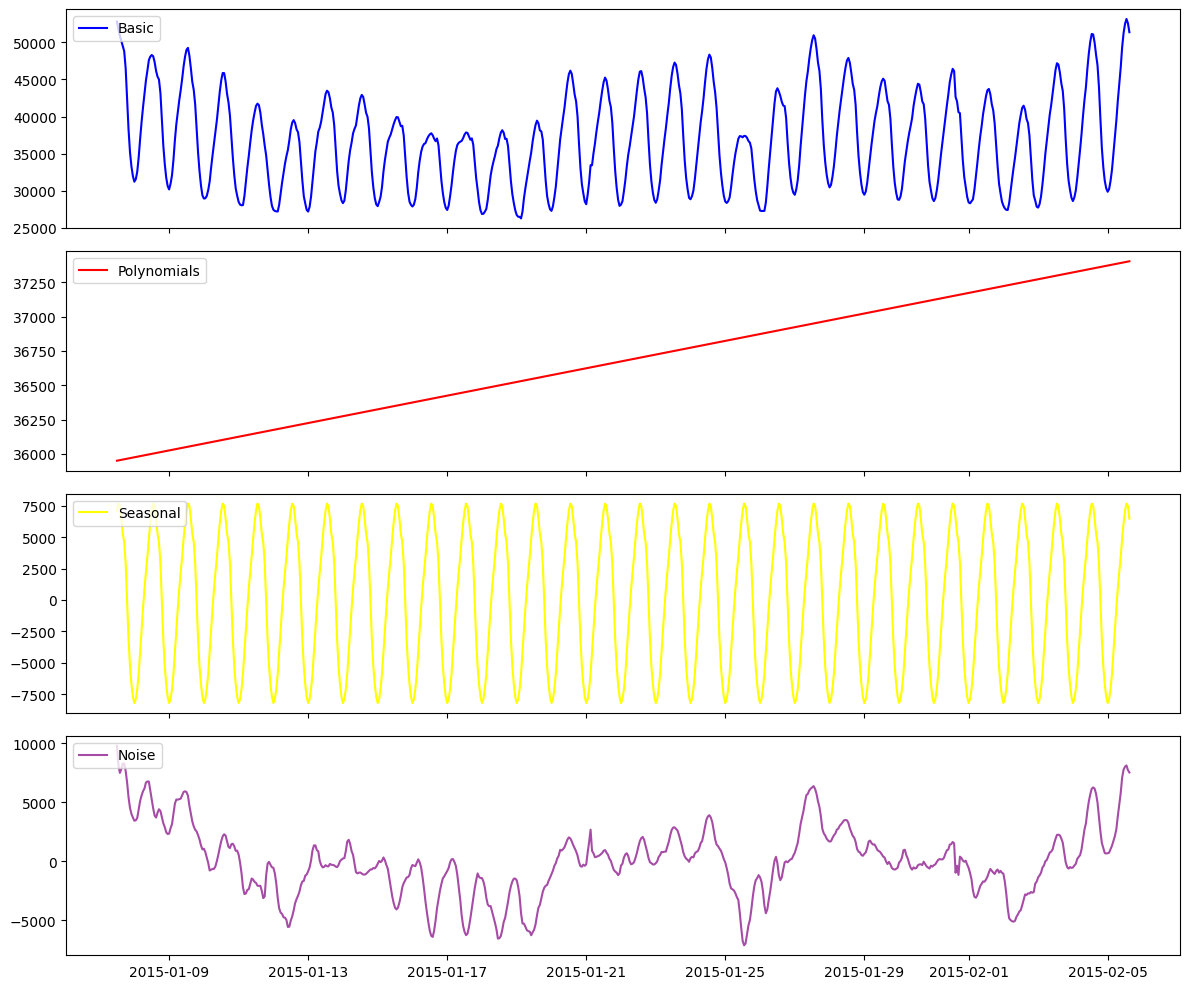

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(train_series, label='Basic', color= 'blue')
axes[0].legend(loc='upper left')
axes[1].plot(m_hat_poly, label='Polynomials', color = 'red')
axes[1].legend(loc='upper left')
axes[2].plot(train_series.index, s_hat, label='Seasonal', color = 'yellow')
axes[2].legend(loc='upper left')
axes[3].plot(y_hat, label='Noise', alpha=0.7, color = 'purple')
axes[3].legend(loc='upper left')
plt.tight_layout()
plt.show()

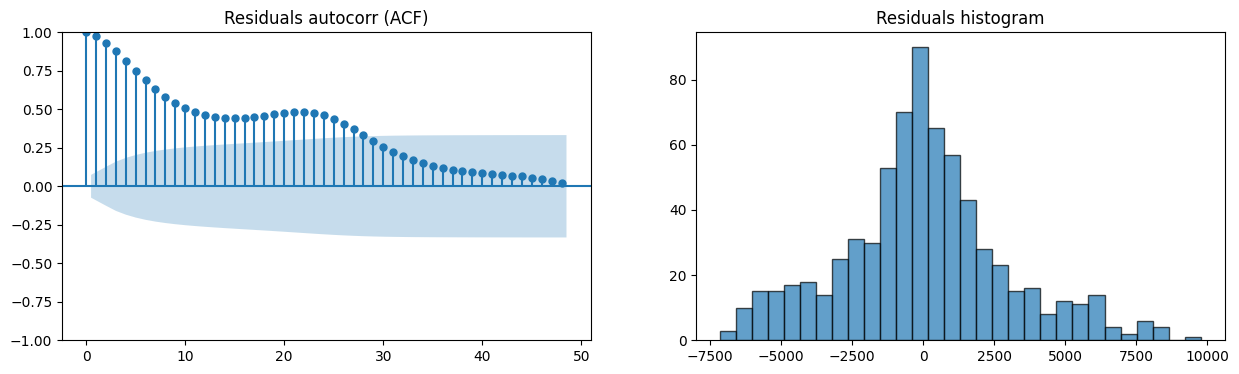

In [ ]:
# task 3

# residual analysis
residuals = y_hat.dropna()
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(residuals, ax=ax[0], lags=48, title='Residuals autocorr (ACF)')
ax[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax[1].set_title('Residuals histogram')
plt.show()

In [39]:
# ljung box test from 1.6 section
ljung_box = acorr_ljungbox(residuals, lags=[24], return_df=True)
print("--- Ljung-Box Test Results ---")
print(ljung_box)

--- Ljung-Box Test Results ---
        lb_stat  lb_pvalue
24  6098.814252        0.0


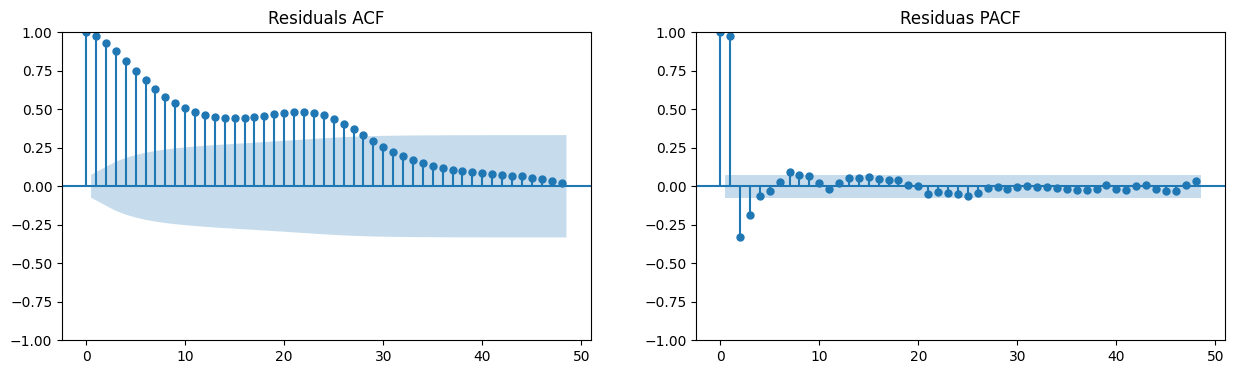

ARIMA(0,0,0) - AIC: 13170.73
ARIMA(0,0,1) - AIC: 12296.96
ARIMA(0,0,2) - AIC: 11630.24
ARIMA(0,0,3) - AIC: 11377.02
ARIMA(1,0,0) - AIC: 10641.93
ARIMA(1,0,1) - AIC: 10357.91
ARIMA(1,0,2) - AIC: 10177.24
ARIMA(1,0,3) - AIC: 10157.35
ARIMA(2,0,0) - AIC: 10157.41
ARIMA(2,0,1) - AIC: 10158.70
ARIMA(2,0,2) - AIC: 10138.44
ARIMA(2,0,3) - AIC: 10136.68
ARIMA(3,0,0) - AIC: 10158.35
ARIMA(3,0,1) - AIC: 10150.62
ARIMA(3,0,2) - AIC: 10136.06
ARIMA(3,0,3) - AIC: 10138.10
---------------------------------------------
SELECTED MODEL: ARIMA(3, 0, 2) with Lowest AIC: 10136.06
---------------------------------------------
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  700
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -5061.032
Date:                Tue, 26 May 2026   AIC                          10136.064
Time:                        21:10:51   BIC                          10

In [ ]:
# task 4

warnings.filterwarnings("ignore")
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(residuals, ax=ax[0], lags=48, title='Residuals ACF')
plot_pacf(residuals, ax=ax[1], lags=48, title='Residuas PACF')
plt.show()

# Grid Search just like in MATLAB
best_aic = np.inf
best_order = None
best_model = None
for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(residuals, order=(p, 0, q))
            results = model.fit()
            print(f"ARIMA({p},0,{q}) - AIC: {results.aic:.2f}")
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p, 0, q)
                best_model = results
        except:
            continue

print("-" * 45)
print(f"SELECTED MODEL: ARIMA{best_order} with Lowest AIC: {best_aic:.2f}")
print("-" * 45)

arima_result = best_model
print(arima_result.summary())

In [ ]:
# task 5

horizon = 24
noise_forecast = arima_result.forecast(steps=horizon).values # forecast

x_vals_future = np.arange(len(train_series), len(train_series) + horizon)
trend_future = np.polyval(poly_coeffs, x_vals_future) # trend extrapolation

future_dates = pd.date_range(start=train_series.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq='h')
seasonal_future = future_dates.hour.map(s_k).values # seasonality extrapolation

arima_final_forecast = trend_future + seasonal_future + noise_forecast # final forecast

mean_forecast = np.full(horizon, train_series.mean()) # mean forecast
naive_forecast = np.full(horizon, train_series.iloc[-1]) # naive forecast
s_naive_forecast = train_series.iloc[-horizon:].values # seasonal naive forecast

predictions = {
    'ARIMA final model forecast': arima_final_forecast,
    'Mean forecast': mean_forecast,
    'Naive forecast': naive_forecast,
    'Seasonal naive forecast': s_naive_forecast
}

print(f"{'Method':<18} | {'MAE':<10} | {'RMSE':<10}")
print("-" * 45)

h7_test_24 = h7_test[:horizon]

for name, pred in predictions.items():
    mae = mean_absolute_error(h7_test_24, pred)
    rmse = np.sqrt(mean_squared_error(h7_test_24, pred))
    print(f"{name:<18} | {mae:<10.4f} | {rmse:<10.4f}")

Method             | MAE        | RMSE      
---------------------------------------------
ARIMA final model forecast | 2822.2526  | 3259.2885 
Mean forecast      | 7763.8240  | 9187.3778 
Naive forecast     | 9869.8750  | 12418.1837
Seasonal naive forecast | 810.5833   | 913.5967  


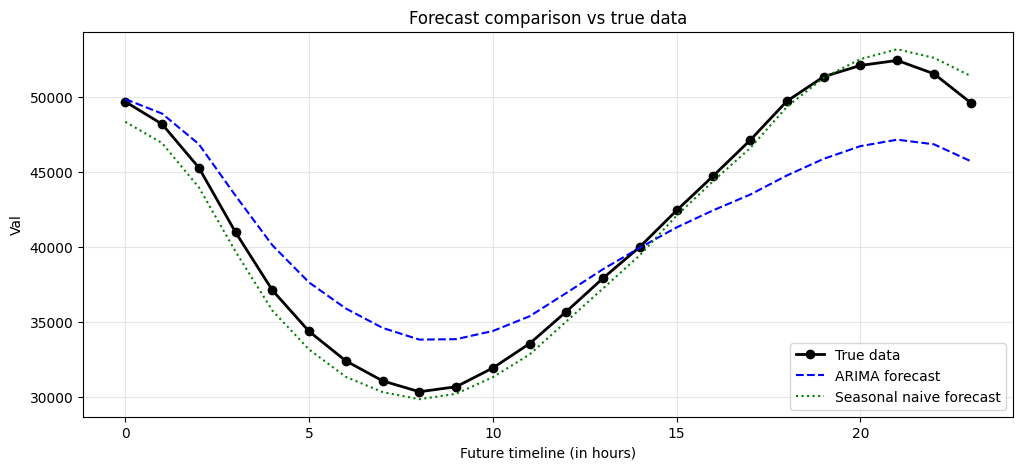

In [57]:
plt.figure(figsize=(12, 5))
plt.plot(np.arange(horizon), h7_test_24, label='True data', color='black', linewidth=2, marker='o')
plt.plot(np.arange(horizon), arima_final_forecast, label='ARIMA forecast', color='blue', linestyle='--')
plt.plot(np.arange(horizon), s_naive_forecast, label='Seasonal naive forecast', color='green', linestyle=':')
plt.title('Forecast comparison vs true data')
plt.xlabel('Future timeline (in hours)')
plt.ylabel('Val')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()